Libraries Loaded


C:\Users\nagar\AppData\Local\Temp\ipykernel_16164\3379849572.py:21: DtypeWarning: Columns (0: # This file was produced by the NASA Exoplanet Archive  http://exoplanetarchive.ipac.caltech.edu, 1: Unnamed: 9, 2: Unnamed: 10, 3: Unnamed: 11, 4: Unnamed: 12, 5: Unnamed: 13, 6: Unnamed: 15, 7: Unnamed: 22, 8: Unnamed: 23, 9: Unnamed: 24, 10: Unnamed: 25, 11: Unnamed: 26, 12: Unnamed: 27, 13: Unnamed: 28, 14: Unnamed: 29, 15: Unnamed: 30, 16: Unnamed: 31, 17: Unnamed: 33, 18: Unnamed: 35, 19: Unnamed: 36, 20: Unnamed: 37, 21: Unnamed: 38, 22: Unnamed: 39, 23: Unnamed: 40, 24: Unnamed: 41, 25: Unnamed: 42, 26: Unnamed: 43, 27: Unnamed: 44, 28: Unnamed: 45, 29: Unnamed: 46, 30: Unnamed: 47, 31: Unnamed: 48, 32: Unnamed: 49, 33: Unnamed: 50, 34: Unnamed: 51, 35: Unnamed: 52, 36: Unnamed: 53, 37: Unnamed: 54, 38: Unnamed: 55, 39: Unnamed: 56, 40: Unnamed: 57, 41: Unnamed: 58, 42: Unnamed: 59, 43: Unnamed: 60, 44: Unnamed: 61, 45: Unnamed: 62, 46: Unnamed: 63, 47: Unnamed: 64, 48: Unnamed: 65, 49

Dataset Shape: (39608, 293)
After removing text columns: (39608, 4)

Target Distribution:
habitable_class
0    39608
Name: count, dtype: int64
Training Shape: (31686, 3)

===== RANDOM FOREST =====
Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      7922

    accuracy                           1.00      7922
   macro avg       1.00      1.00      1.00      7922
weighted avg       1.00      1.00      1.00      7922



c:\Users\nagar\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:620: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


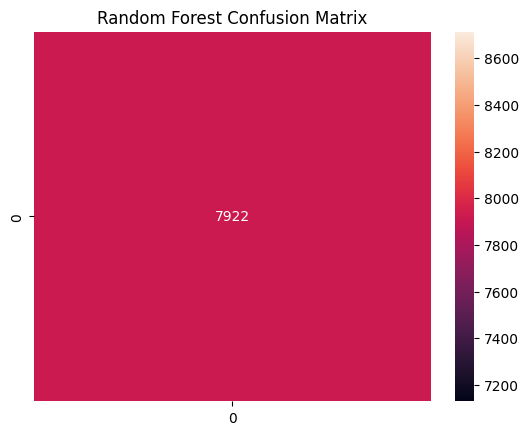


===== XGBOOST =====
Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      7922

    accuracy                           1.00      7922
   macro avg       1.00      1.00      1.00      7922
weighted avg       1.00      1.00      1.00      7922



c:\Users\nagar\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:620: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


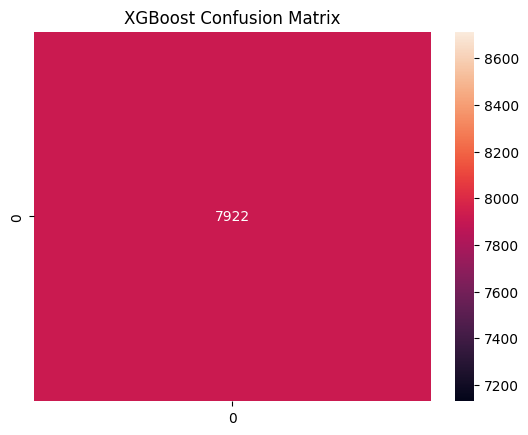

Models Saved
Ranking File Saved


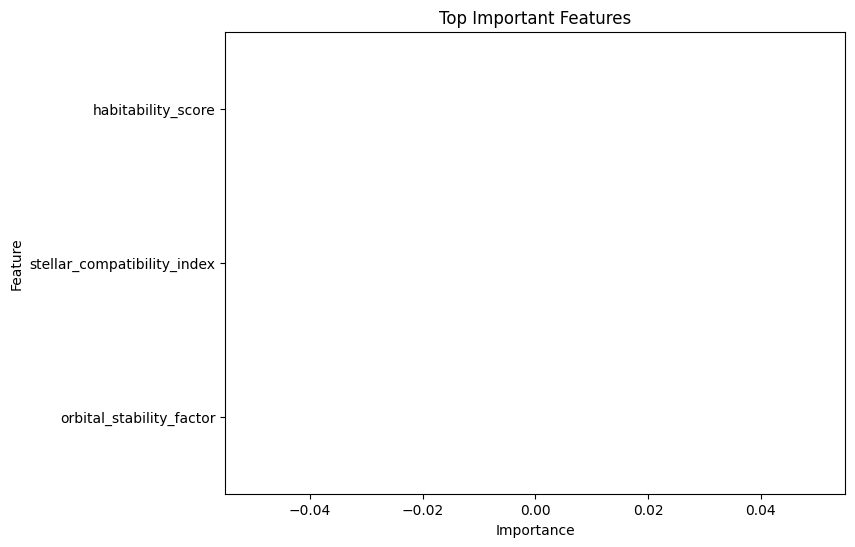


✅ ML MODEL TRAINING COMPLETED SUCCESSFULLY


In [ ]:
# ============================================================
# EXOHABITAI – FINAL model
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from xgboost import XGBClassifier

print("Libraries Loaded")

# ------------------------------------------------
# 1 LOAD DATA
# ------------------------------------------------
df = pd.read_csv("preprocessed.csv")

print("Dataset Shape:", df.shape)

# ------------------------------------------------
# 2 KEEP ONLY NUMERIC COLUMNS
# ------------------------------------------------
df = df.select_dtypes(include=np.number)

print("After removing text columns:", df.shape)

# ------------------------------------------------
# 3 CHECK TARGET VARIABLE
# ------------------------------------------------
print("\nTarget Distribution:")
print(df["habitable_class"].value_counts())

# ------------------------------------------------
# 4 SPLIT FEATURES AND TARGET
# ------------------------------------------------
X = df.drop("habitable_class", axis=1)
y = df["habitable_class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training Shape:", X_train.shape)

# ------------------------------------------------
# 5 RANDOM FOREST MODEL
# ------------------------------------------------
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

# SAFE probability extraction
rf_prob = rf_model.predict_proba(X_test)
if rf_prob.shape[1] > 1:
    y_prob_rf = rf_prob[:,1]
else:
    y_prob_rf = rf_prob[:,0]

# ------------------------------------------------
# 6 XGBOOST MODEL
# ------------------------------------------------
xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    eval_metric="logloss",
    random_state=42
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

xgb_prob = xgb_model.predict_proba(X_test)
if xgb_prob.shape[1] > 1:
    y_prob_xgb = xgb_prob[:,1]
else:
    y_prob_xgb = xgb_prob[:,0]

# ------------------------------------------------
# 7 MODEL EVALUATION
# ------------------------------------------------
print("\n===== RANDOM FOREST =====")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Random Forest Confusion Matrix")
plt.show()

print("\n===== XGBOOST =====")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))

cm = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm, annot=True, fmt="d")
plt.title("XGBoost Confusion Matrix")
plt.show()

# ------------------------------------------------
# 8 SAVE MODELS
# ------------------------------------------------
joblib.dump(rf_model, "random_forest.pkl")
joblib.dump(xgb_model, "xgboost.pkl")

print("Models Saved")

# ------------------------------------------------
# 9 HABITABILITY RANKING
# ------------------------------------------------
prob_all = xgb_model.predict_proba(X)

if prob_all.shape[1] > 1:
    df["habitability_probability"] = prob_all[:,1]
else:
    df["habitability_probability"] = prob_all[:,0]

df_sorted = df.sort_values(
    by="habitability_probability",
    ascending=False
)

df_sorted.to_csv("habitability_ranked.csv", index=False)

print("Ranking File Saved")

# ------------------------------------------------
# 10 FEATURE IMPORTANCE
# ------------------------------------------------
importance = xgb_model.feature_importances_

importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(8,6))
sns.barplot(
    x="Importance",
    y="Feature",
    data=importance_df.head(10)
)
plt.title("Top Important Features")
plt.show()

print("\n✅ ML MODEL TRAINING COMPLETED SUCCESSFULLY")
